# Konkan Railway Delay Analysis — Data Quality Report

This notebook performs a data quality assessment on train delay records for the Konkan Railway route, ahead of downstream delay-prediction / trend analysis.

**What this covers:**
- Filtering the full delay dataset down to Konkan Railway trains
- Historical coverage per train (how much data we actually have)
- Missing value analysis (by train, station, and date)
- Delay distribution, negative values, and extreme outliers
- Average delay by station, train, and day
- Duplicate record check
- Building a clean reference list of Konkan trains


## 1. Load Data

Load the combined delay dataset.

In [1]:
import pandas as pd

df = pd.read_csv('combined_delay.csv')

## 2. Dataset Overview

Quick sanity check: shape, date range, number of unique trains, and null counts.

In [2]:
print(df.shape)
print(df['date'].min(), df['date'].max())
print(df['train_no'].nunique())
print(df.isna().sum())

(38428703, 5)
2025-02-08 2026-02-07
7033
date                  0
station_no            0
station_name          0
delay           1874271
train_no              0
dtype: int64


## 3. Filter to Konkan Railway Trains

Restrict the dataset to the known list of Konkan Railway train numbers.

In [3]:
konkan_trains = [10103,10104,20111,20112,16345,16346,12619,12620,12617,12618,
                  12133,12134,11003,11004,16595,16596,16585,16586,10105,10106,
                  20645,20646,10107,10108,12431,12432,16515,16516,22229,22230,
                  22119,22120,12449,12450,11204,11205,22114,22115,20923,20934,22475,22476,22629,22630,16333,16334,10115,10116]  # add rest of your list

kdf = df[df['train_no'].isin(konkan_trains)]

print("Konkan rows:", kdf.shape)
print("Trains actually present:", kdf['train_no'].nunique(), "of", len(konkan_trains))
print("Date coverage per train:", kdf.groupby('train_no')['date'].nunique().describe())
print("Null delay % per train:\n", kdf.groupby('train_no')['delay'].apply(lambda x: x.isna().mean()*100))
print("Delay value range:", kdf['delay'].min(), kdf['delay'].max())

Konkan rows: (268902, 5)
Trains actually present: 46 of 48
Date coverage per train: count     46.000000
mean     243.108696
std      129.580902
min       52.000000
25%      104.000000
50%      313.000000
75%      365.000000
max      365.000000
Name: date, dtype: float64
Null delay % per train:
 train_no
10103     0.041096
10104     0.041096
10105     4.193303
10106     4.193303
10107     7.587859
10108     7.587859
10115     6.189904
10116     0.000000
11003     2.765819
11004     2.752772
12133     0.000000
12134     2.977169
12431     0.000000
12432     0.000000
12449     5.656109
12450    10.634921
12617     2.498630
12618     0.000000
12619     0.000000
12620     0.000000
16333     1.794872
16334     5.263158
16345     1.079117
16346     2.991781
16515    17.948718
16516    18.471338
16585     0.000000
16586     0.000000
16595     0.000000
16596     0.000000
20111     0.043259
20112     0.057678
20645     0.000000
20646     0.000000
20923     0.000000
20934     2.297009
22114     3

## 4. Historical Coverage per Train

For each train, check how many distinct days of data and how many stations are represented. This tells us which trains have enough history to be usable for analysis.

In [4]:
coverage = (
    kdf.groupby("train_no")
       .agg(
           days_available=("date", "nunique"),
           total_records=("date", "count"),
           stations=("station_name", "nunique")
       )
       .sort_values("days_available", ascending=False)
)

print(coverage)

          days_available  total_records  stations
train_no                                         
10103                365           7300        20
10104                365           7300        20
10105                365          13140        36
10106                365          13140        36
11003                365           7665        21
11004                365           7665        21
12134                365           5475        15
12133                365           5475        15
16586                365           9125        25
16585                365           9125        25
12619                365           8395        23
12620                365           7665        21
12617                365          18250        50
12618                365          15695        43
16595                365           8030        22
16596                365           8030        22
20112                365           6935        19
20111                365           6935        19


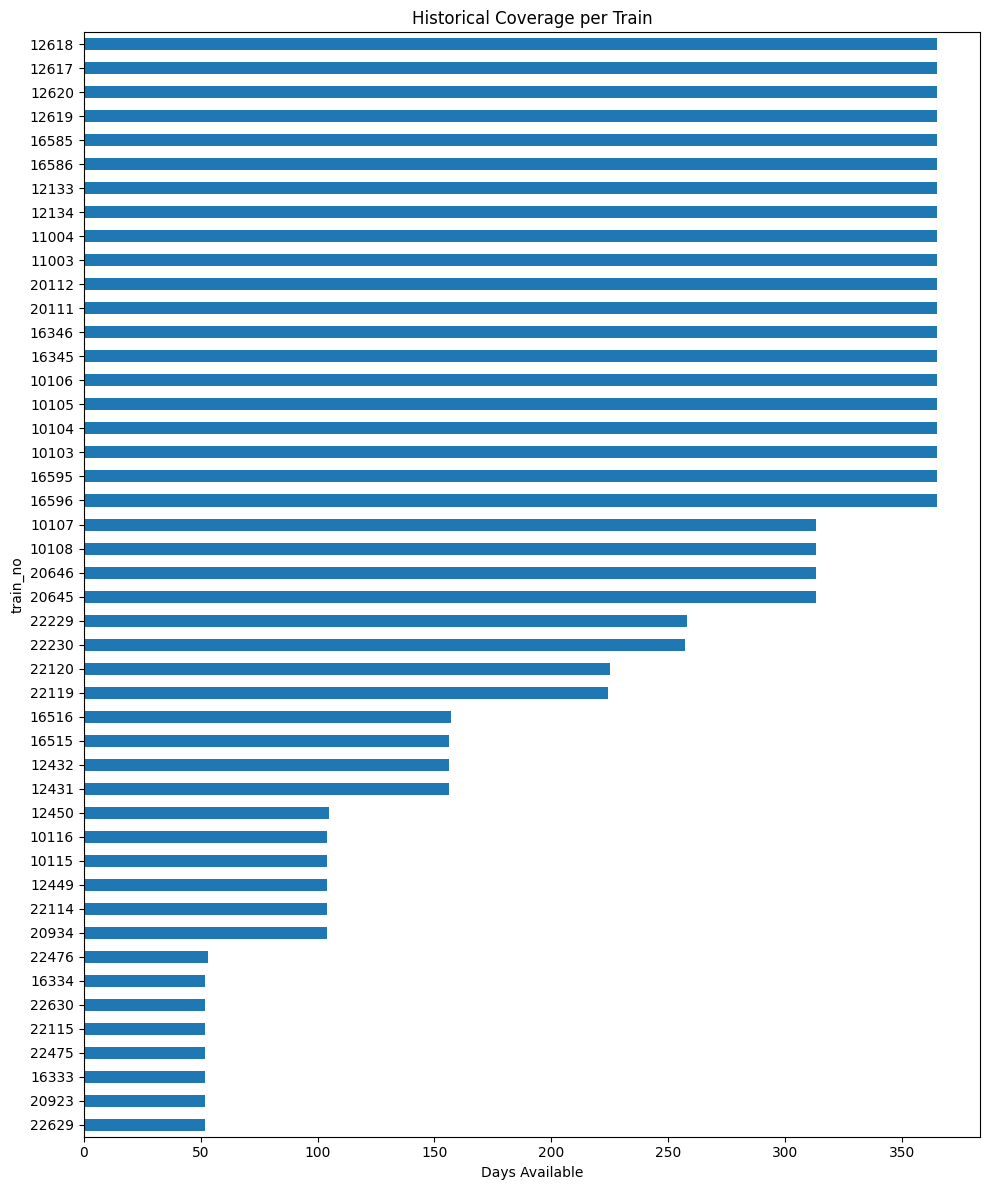

In [5]:
import matplotlib.pyplot as plt

coverage["days_available"].sort_values().plot(
    kind="barh",
    figsize=(10,12)
)

plt.xlabel("Days Available")
plt.title("Historical Coverage per Train")
plt.tight_layout()
plt.show()

In [6]:
def coverage_category(days):
    if days >= 300:
        return "High"
    elif days >= 150:
        return "Medium"
    else:
        return "Low"

coverage["coverage_level"] = coverage["days_available"].apply(coverage_category)

print(coverage)

          days_available  total_records  stations coverage_level
train_no                                                        
10103                365           7300        20           High
10104                365           7300        20           High
10105                365          13140        36           High
10106                365          13140        36           High
11003                365           7665        21           High
11004                365           7665        21           High
12134                365           5475        15           High
12133                365           5475        15           High
16586                365           9125        25           High
16585                365           9125        25           High
12619                365           8395        23           High
12620                365           7665        21           High
12617                365          18250        50           High
12618                365 

## 5. Missing Delay Values

Check what fraction of delay records are missing, broken down by train, by station, and over time — to spot whether missingness is random or concentrated.

In [7]:
missing_train = (
    kdf.groupby("train_no")["delay"]
       .apply(lambda x: x.isna().mean()*100)
       .sort_values(ascending=False)
       .reset_index(name="missing_percent")
)

print(missing_train)

    train_no  missing_percent
0      16516        18.471338
1      16515        17.948718
2      12450        10.634921
3      22115         9.615385
4      10107         7.587859
5      10108         7.587859
6      22476         6.713471
7      10115         6.189904
8      12449         5.656109
9      16334         5.263158
10     22120         5.086420
11     22475         4.258242
12     10105         4.193303
13     10106         4.193303
14     22114         3.448276
15     16346         2.991781
16     12134         2.977169
17     11003         2.765819
18     11004         2.752772
19     12617         2.498630
20     20934         2.297009
21     16333         1.794872
22     16345         1.079117
23     20112         0.057678
24     22119         0.049603
25     20111         0.043259
26     22229         0.043066
27     10103         0.041096
28     10104         0.041096
29     10116         0.000000
30     12432         0.000000
31     12431         0.000000
32     121

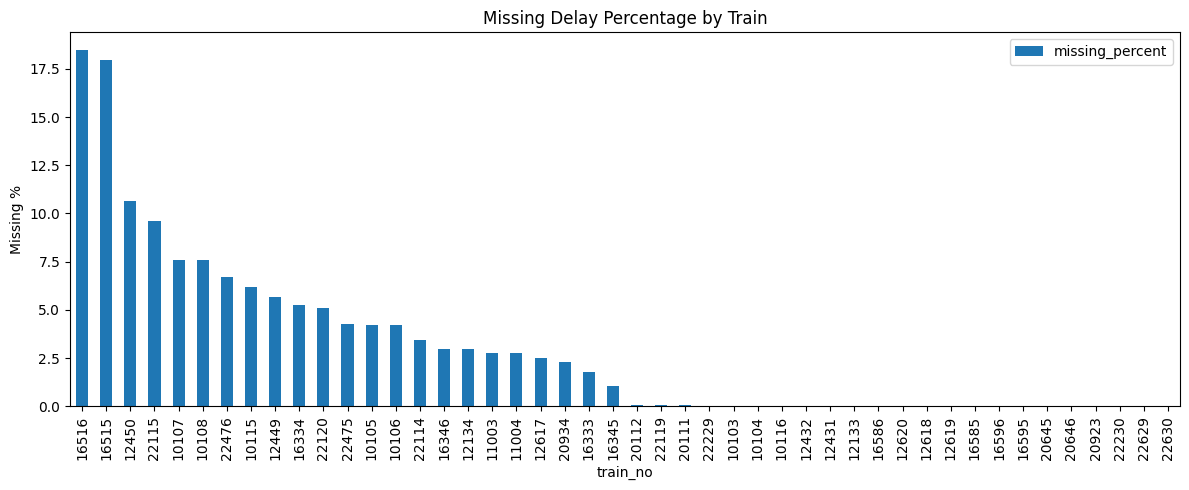

In [8]:
missing_train.plot(
    x="train_no",
    y="missing_percent",
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Missing %")
plt.title("Missing Delay Percentage by Train")
plt.tight_layout()
plt.show()

In [9]:
station_missing = (
    kdf.groupby("station_name")["delay"]
       .apply(lambda x: x.isna().mean()*100)
       .sort_values(ascending=False)
       .reset_index(name="missing_percent")
)

print(station_missing.head(30))

   station_name  missing_percent
0           KDV        99.178082
1          KARD        99.038462
2          NVRD        98.082192
3          KCVL        98.076923
4          BDMJ        93.779904
5           PEN        57.808219
6           UDN        57.006369
7           KOL        46.575342
8           ANO        46.575342
9           PDD        46.325879
10         SHMI        46.325879
11          HAA        44.728435
12         MRJN        44.728435
13          IGP        25.753425
14         BGNR        18.210863
15         NMGA        18.210863
16          BAW        18.210863
17           YY        18.210863
18         SBGA        18.210863
19         ROHA        16.225547
20         PRYJ        12.500000
21          GYN        12.500000
22          BSB        11.538462
23         RAJP        10.301370
24         CSMT         8.623970
25          TIR         5.696560
26          YPR         5.465005
27         KIGL         5.465005
28         CNPA         5.465005
29        

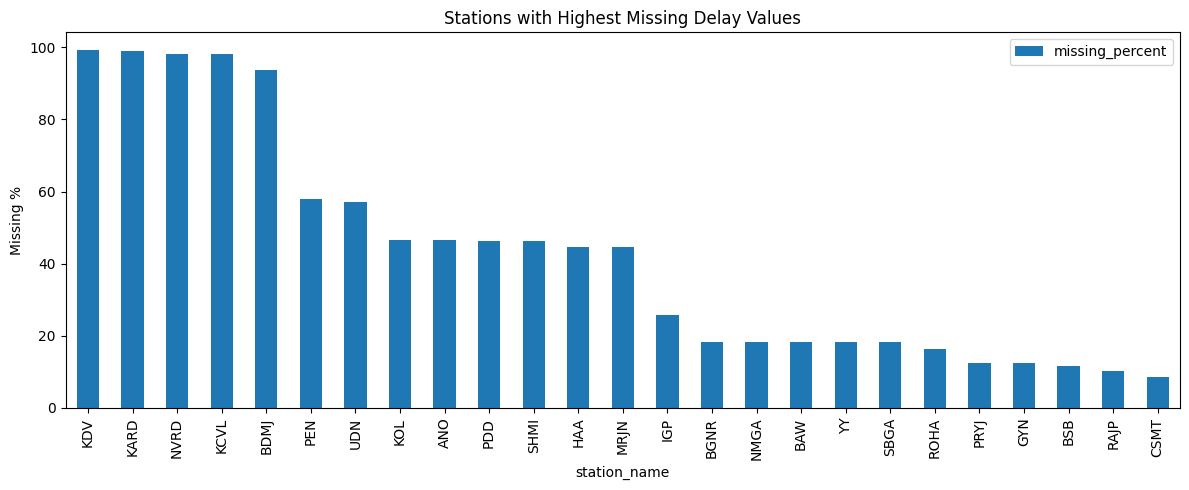

In [10]:
station_missing.head(25).plot(
    x="station_name",
    y="missing_percent",
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Missing %")
plt.title("Stations with Highest Missing Delay Values")
plt.tight_layout()
plt.show()

In [11]:
date_missing = (
    kdf.groupby("date")["delay"]
       .apply(lambda x: x.isna().mean()*100)
       .reset_index(name="missing_percent")
)

print(date_missing.sort_values("missing_percent", ascending=False).head(20))

           date  missing_percent
21   2025-03-01         5.342466
258  2025-10-24         4.651163
259  2025-10-25         4.383562
105  2025-05-24         4.383562
255  2025-10-21         4.359673
252  2025-10-18         4.353933
245  2025-10-11         4.353933
256  2025-10-22         4.315660
18   2025-02-26         4.315660
273  2025-11-08         4.246575
280  2025-11-15         4.246575
308  2025-12-13         4.246575
294  2025-11-29         4.246575
287  2025-11-22         4.246575
301  2025-12-06         4.246575
266  2025-11-01         4.246575
275  2025-11-10         4.238411
310  2025-12-15         4.238411
303  2025-12-08         4.238411
282  2025-11-17         4.238411


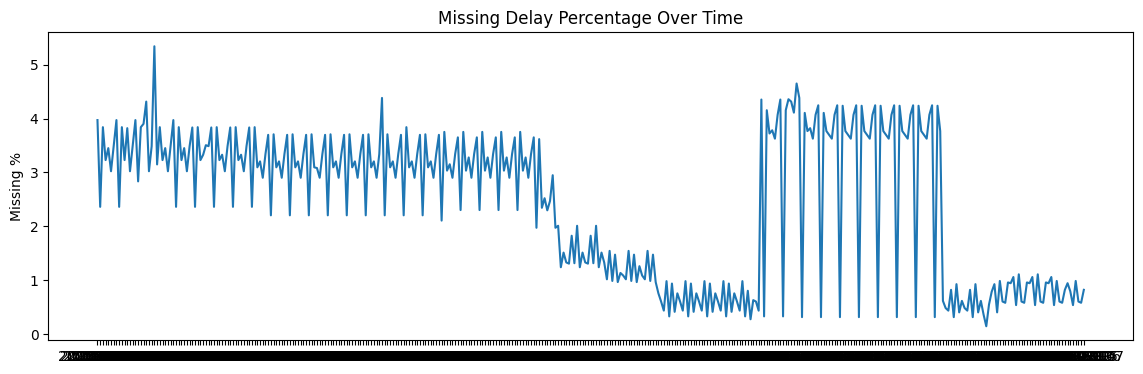

In [12]:
date_missing = date_missing.sort_values("date")

plt.figure(figsize=(14,4))
plt.plot(date_missing["date"], date_missing["missing_percent"])
plt.title("Missing Delay Percentage Over Time")
plt.ylabel("Missing %")
plt.show()

## 6. Delay Distribution & Outliers

Look at the overall shape of delay values, then flag suspicious records: negative delays (likely data entry issues) and extreme delays (>1000 minutes).

In [13]:
kdf["delay"].describe()

count    262282.000000
mean         38.354172
std          50.004307
min         -88.000000
25%           8.000000
50%          25.000000
75%          51.000000
max        2774.000000
Name: delay, dtype: float64

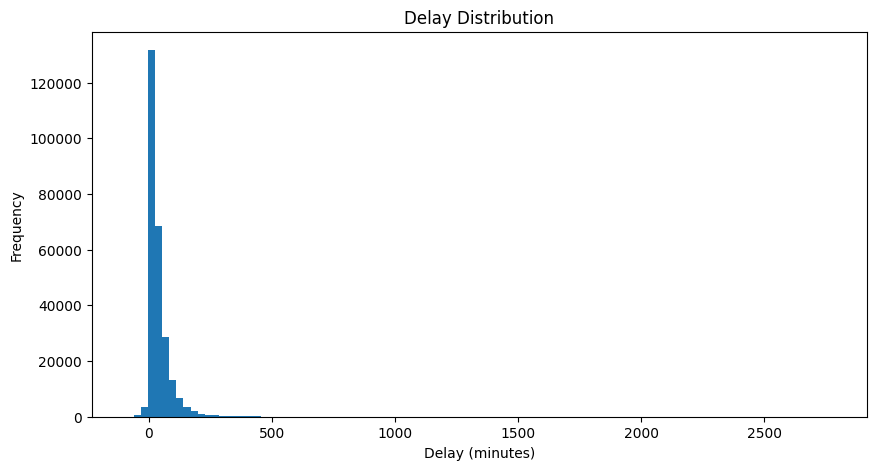

In [14]:
plt.figure(figsize=(10,5))

plt.hist(
    kdf["delay"].dropna(),
    bins=100
)

plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.title("Delay Distribution")
plt.show()

In [15]:
negative = kdf[kdf["delay"] < 0]

print("Negative records:", len(negative))

print(negative.head(20))

Negative records: 4608
              date  station_no station_name  delay  train_no
824617  2025-02-11          20          MAO  -10.0     10103
824618  2025-02-12          20          MAO  -17.0     10103
824620  2025-02-14          20          MAO  -16.0     10103
824628  2025-02-22          20          MAO  -31.0     10103
824629  2025-02-23          20          MAO   -1.0     10103
824630  2025-02-24          20          MAO  -26.0     10103
824631  2025-02-25          20          MAO  -15.0     10103
824634  2025-02-28          20          MAO   -1.0     10103
824636  2025-03-02          20          MAO  -19.0     10103
824637  2025-03-03          20          MAO  -10.0     10103
824638  2025-03-04          20          MAO  -10.0     10103
824639  2025-03-05          20          MAO   -9.0     10103
824641  2025-03-07          20          MAO  -22.0     10103
824643  2025-03-09          20          MAO  -12.0     10103
824644  2025-03-10          20          MAO  -13.0     10103
8

In [16]:
negative.groupby("train_no").size().sort_values(ascending=False)

train_no
10107    266
20646    234
16595    228
10108    215
12133    206
16586    200
16585    192
11004    188
16345    186
12617    186
16346    173
16596    161
20645    145
22229    139
10103    130
12618    125
11003    124
12619    115
12432    113
10105     94
10104     87
12431     85
10106     84
20934     82
12620     81
22119     76
10115     70
20111     67
16515     61
20112     58
16333     43
22629     43
22475     38
16516     37
20923     37
12450     36
16334     36
10116     34
22476     32
22114     29
22630     25
22230     18
22115     17
22120      9
12134      3
dtype: int64

In [17]:
extreme = kdf[kdf["delay"] > 1000]

print(extreme.shape)

extreme.sort_values("delay", ascending=False).head(50)

(8, 5)


,date,station_no,station_name,delay,train_no
915250,2025-06-10,20,TNA,2774.0,11004
915615,2025-06-10,21,DR,2753.0,11004
866010,2025-11-29,24,MAQ,2750.0,10107
915689,2025-08-23,21,DR,1768.0,11004
12447587,2026-01-03,25,MRDW,1471.0,16585
865928,2025-08-26,24,MAQ,1405.0,10107
19281317,2025-04-09,24,BSR,1316.0,22475
3321585,2025-12-31,6,BSR,1196.0,12432


In [18]:
largest = (
    kdf.sort_values("delay", ascending=False)
       .head(30)
)

print(largest)

                date  station_no station_name   delay  train_no
915250    2025-06-10          20          TNA  2774.0     11004
915615    2025-06-10          21           DR  2753.0     11004
866010    2025-11-29          24          MAQ  2750.0     10107
915689    2025-08-23          21           DR  1768.0     11004
12447587  2026-01-03          25         MRDW  1471.0     16585
865928    2025-08-26          24          MAQ  1405.0     10107
19281317  2025-04-09          24          BSR  1316.0     22475
3321585   2025-12-31           6          BSR  1196.0     12432
3321589   2026-01-11           6          BSR   916.0     12432
858317    2025-06-11          36         DIVA   839.0     10106
18627841  2025-02-26           3          BXR   818.0     20934
18627737  2025-02-26           2          ARA   813.0     20934
3358920   2025-08-19          17          CDG   807.0     12449
3358816   2025-08-19          16          UMB   798.0     12449
18627945  2025-02-26           4        

In [19]:
extreme.groupby("date").size().sort_values(ascending=False)

date
2025-06-10    2
2025-04-09    1
2025-08-23    1
2025-08-26    1
2025-11-29    1
2025-12-31    1
2026-01-03    1
dtype: int64

In [20]:
extreme.groupby("station_name").size().sort_values(ascending=False)

station_name
BSR     2
DR      2
MAQ     2
MRDW    1
TNA     1
dtype: int64

## 7. Delay Patterns

Average delay by station, by train, and by day — to identify chronic problem points versus one-off bad days.

In [21]:
station_delay = (
    kdf.groupby("station_name")["delay"]
       .mean()
       .sort_values(ascending=False)
)

print(station_delay.head(30))

station_name
KARD    69.000000
NIV     67.078082
ANO     66.700000
PNP     64.215311
VRLI    61.326027
KKW     60.786079
KRMI    60.743531
THVM    59.151687
ADVI    57.897717
RAJP    57.520464
PERN    57.428088
KUDL    57.422869
SRTL    56.161866
SNDD    56.010210
VBW     56.002740
KTE     55.873786
VINH    55.256164
SGR     54.062466
CHI     53.333007
BXR     52.817308
RN      52.349392
SVX     51.924658
ACRN    51.819178
KFD     51.041096
SAPE    51.027397
AVRD    50.928082
KYN     50.473973
CDG     50.377990
VID     50.320091
KRPN    49.936986
Name: delay, dtype: float64


In [22]:
train_delay = (
    kdf.groupby("train_no")["delay"]
       .mean()
       .sort_values(ascending=False)
)

print(train_delay)

train_no
12134    76.556288
10103    72.304372
16345    59.378024
22120    59.312175
12449    58.119305
12619    57.275640
20111    53.368869
22115    49.434988
22114    47.839629
12450    47.779159
10105    47.143141
10106    46.824609
12618    44.947690
11004    41.742688
10116    40.425641
12620    40.227136
12133    39.434521
16334    38.567664
22475    38.185557
22119    38.007940
22476    36.801976
10104    35.953680
20112    33.496898
10108    32.721262
12432    32.590049
11003    32.500335
12617    30.533551
16585    30.129315
16346    29.819928
22629    29.553571
20934    26.804811
16595    26.054919
20923    24.482517
10115    23.315183
16596    22.682316
16333    21.764360
22630    21.551511
10107    20.891386
16586    20.844384
12431    20.550366
22230    16.888889
16516    15.051875
22229    13.151228
16515    12.394687
20645    11.698083
20646     3.988818
Name: delay, dtype: float64


In [23]:
worst_days = (
    kdf.groupby("date")["delay"]
       .mean()
       .sort_values(ascending=False)
)

print(worst_days.head(20))

date
2025-08-17    91.855482
2025-08-19    89.355153
2025-06-16    86.140669
2025-08-18    80.507483
2026-01-31    77.498619
2025-05-25    77.077295
2025-08-16    76.924394
2025-05-24    75.777937
2026-01-29    74.911192
2025-05-26    72.012380
2026-02-01    71.275040
2026-01-30    70.804094
2025-10-22    69.689433
2025-06-14    69.348506
2026-02-02    68.991989
2025-06-15    67.652318
2026-02-05    67.038929
2025-08-26    66.167131
2025-11-09    65.938389
2026-02-06    65.713450
Name: delay, dtype: float64


## 8. Duplicate Records

Check for fully duplicated rows in the filtered dataset.

In [24]:
duplicates = kdf.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


## 9. Summary Statistics

Consolidated snapshot of the cleaned Konkan dataset.

In [25]:
print("="*60)

print("Rows:", len(kdf))
print("Trains:", kdf.train_no.nunique())
print("Stations:", kdf.station_name.nunique())

print()

print("Date Range")
print(kdf.date.min(), "to", kdf.date.max())

print()

print("Missing Delay %")
print(round(kdf.delay.isna().mean()*100,2), "%")

print()

print("Delay Range")
print(kdf.delay.min(), "to", kdf.delay.max())

print("="*60)

Rows: 268902
Trains: 46
Stations: 223

Date Range
2025-02-08 to 2026-02-07

Missing Delay %
2.46 %

Delay Range
-88.0 to 2774.0


## 10. Negative Delays by Station

Where are the negative (likely erroneous) delay values concentrated?

In [26]:
negative.groupby("station_name").size()

station_name
BDTS     34
CBE      38
CSMT    175
DIVA     84
DR      213
ERS     125
GIMB     37
HSR      32
KAWR    289
KRMI     17
LTT     283
MAJN    206
MAO     967
MAQ     526
MRDW    192
NZM     271
SBC     161
SMVB    200
SWV     218
TEN      43
TVC     342
UDN      82
VRL      36
YPR      37
dtype: int64

## 11. Build Clean Train Reference List

`train_details.csv` has duplicate rows for a few trains (e.g. dual T18/PRM classification for Vande Bharat trains). Deduplicate and save a clean 48-train reference list for reuse in later notebooks. Renamed the working variable to `train_ref` here to avoid overwriting the `kdf` (delay data) used throughout the rest of this notebook.

In [27]:
td = pd.read_csv("train_details.csv")

# train_details.csv has duplicate rows for a few trains (two type_code
# classifications, e.g. T18-TRAINS and PRM-TRAINS for Vande Bharat trains) —
# keep first occurrence so each train_no appears once
train_ref = td[td["train_no"].isin(konkan_trains)].drop_duplicates(subset="train_no", keep="first")
train_ref = train_ref.sort_values("train_no").reset_index(drop=True)

train_ref.to_csv("konkan_train_list.csv", index=False)
print(train_ref.shape)  # should be (48, 3)

(48, 3)


In [28]:
train_ref_check = pd.read_csv('konkan_train_list.csv')

train_ref_check.head()

,train_no,train_name,type_code
0,10103,MANDOVI EXPRESS,EXP-TRAINS
1,10104,MANDOVI EXPRESS,EXP-TRAINS
2,10105,SINDHUDURG EXP,EXP-TRAINS
3,10106,SINDHUDURG EXP,EXP-TRAINS
4,10107,MAO MAQ MEMU EXP,EXP-TRAINS


## Key Findings

- **Coverage:** 46/48 target trains present; a few (e.g. 22119, 22120) have only ~224–225 days vs. the full 365 — flag before time-based comparisons.
- **Missing delays:** 2.46% overall (6,620 rows). Concentrated, not random — trains 16515/16516 hit 18% missing while 15+ trains have 0%; stations KDV, KARD, NVRD, KCVL, BDMJ are missing 90%+ (likely untracked, not lost data).
- **Outliers:** Delay range -88 to 2774 min (mean 38, median 25). 4,608 negative records (~1.7%), concentrated in train 10107 and stations MAO/MAQ — needs a clear handling rule. Only 8 extreme records (>1000 min), worth spot-checking rather than auto-dropping.
- **Patterns:** Trains 12134 and 10103 have the highest average delay; worst days exceed 90 min avg, suggesting a few disruption events rather than a steady trend.
- **Duplicates:** 0 found.
- **Train reference:** Deduplicated `train_details.csv` down to a clean 48-row list.